优化结果：y = 2.540986570048328x + 0.8463327323323037
解析解：y = 2.513793267336655x + 1.0271871459226323


d:\Users\zyl\anaconda3\envs\pytorchgpu\lib\site-packages\matplotlib\animation.py:872: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


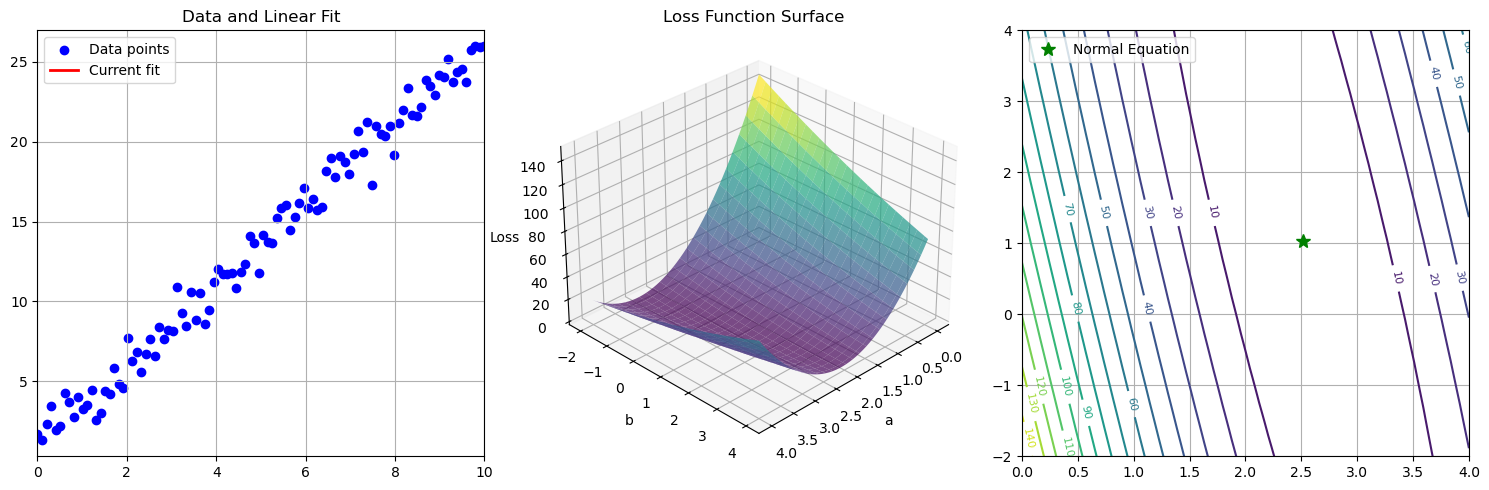

KeyboardInterrupt: 

In [2]:
# Author: Yanzeng Li
# Date: 2025-10-13
# # Description: '使用梯度下降拟合线性方程'

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

np.random.seed(42)
true_a, true_b = 2.5, 1.2
n_samples = 100
noise_level = 1

# 生成线性分布 y = ax + b 的数据
x = np.linspace(0, 10, n_samples)
y = true_a * x + true_b + np.random.normal(0, noise_level, n_samples)
# print(y)
# 梯度下降参数
learning_rate = 0.01
n_iterations = 500

a_history, b_history = [], []

# 初始化参数
a, b = 0.01, 0.01

# 运行梯度下降
for i in range(n_iterations):
    # 计算预测值和误差
    y_pred = a * x + b
    error = y_pred - y
    
    # 计算梯度
    grad_a = np.mean(error * x)
    grad_b = np.mean(error)
    
    # 更新参数
    a -= learning_rate * grad_a
    b -= learning_rate * grad_b
    
    # 记录历史
    a_history.append(a)
    b_history.append(b)


print(f"优化结果：y = {a}x + {b}")


# 计算正规方程解（解析解）
X = np.vstack([x, np.ones(len(x))]).T
theta_normal = np.linalg.inv(X.T @ X) @ X.T @ y
a_normal, b_normal = theta_normal

print(f"解析解：y = {a_normal}x + {b_normal}")


"""
后面全部都是绘图和动画了，同学可以无视
"""
a_grid = np.linspace(0, 4, 50)
b_grid = np.linspace(-2, 4, 50)
A, B = np.meshgrid(a_grid, b_grid)
loss = np.zeros_like(A)

for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        y_pred = A[i,j] * x + B[i,j]
        loss[i,j] = np.mean((y_pred - y)**2) / 2

fig = plt.figure(figsize=(15, 5))

# 图1: 数据点和拟合线
ax1 = fig.add_subplot(1, 3, 1)
ax1.scatter(x, y, c='blue', label='Data points')
line, = ax1.plot([], [], 'r-', linewidth=2, label='Current fit')
ax1.set_xlim(0, 10)
ax1.set_ylim(min(y)-1, max(y)+1)
ax1.set_title('Data and Linear Fit')
ax1.legend()
ax1.grid(True)

# 图2: 损失函数曲面
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax2.plot_surface(A, B, loss, cmap='viridis', alpha=0.7, rstride=2, cstride=2)
path = ax2.plot([], [], [], 'r-', linewidth=2)[0]
point = ax2.plot([], [], [], 'ro')[0]
ax2.set_xlabel('a')
ax2.set_ylabel('b')
ax2.set_zlabel('Loss')
ax2.set_title('Loss Function Surface')
ax2.view_init(elev=30, azim=45)

# 图3: 损失函数等高线图
ax3 = fig.add_subplot(1, 3, 3)
contour = ax3.contour(A, B, loss, levels=15, cmap='viridis')
ax3.clabel(contour, inline=True, fontsize=8)
path2 = ax3.plot([], [], 'r-', linewidth=2)[0]
point2 = ax3.plot([], [], 'ro')[0]
ax3.plot(a_normal, b_normal, 'g*', markersize=10, label='Normal Equation')
ax3.legend()
ax3.grid(True)

plt.tight_layout()

path_coords = []
for a_val, b_val in zip(a_history, b_history):
    a_idx = np.argmin(np.abs(a_grid - a_val))
    b_idx = np.argmin(np.abs(b_grid - b_val))
    path_coords.append((a_val, b_val, loss[b_idx, a_idx]))
path_coords = np.array(path_coords).T


def update(frame):
    current_a, current_b = a_history[frame], b_history[frame]    
    line.set_data(x, current_a * x + current_b)
    path.set_data(path_coords[0, :frame+1], path_coords[1, :frame+1])
    path.set_3d_properties(path_coords[2, :frame+1])
    point.set_data([current_a], [current_b])
    point.set_3d_properties([path_coords[2, frame]])
    path2.set_data(a_history[:frame+1], b_history[:frame+1])
    point2.set_data([current_a], [current_b])
    ax1.set_title(f'Iteration {frame}: y = {current_a:.2f}x + {current_b:.2f}')
    return line, path, point, path2, point2


ani = FuncAnimation(
    fig, 
    update, 
    frames=range(n_iterations),
    interval=20,
    blit=False,
    cache_frame_data=False,  # 禁用缓存
    repeat=False
)

plt.ion()
plt.show(block=True)

while True:
    plt.pause(0.1)

优化结果：theta = [-2.2106899   4.06048478  2.1656103 ]


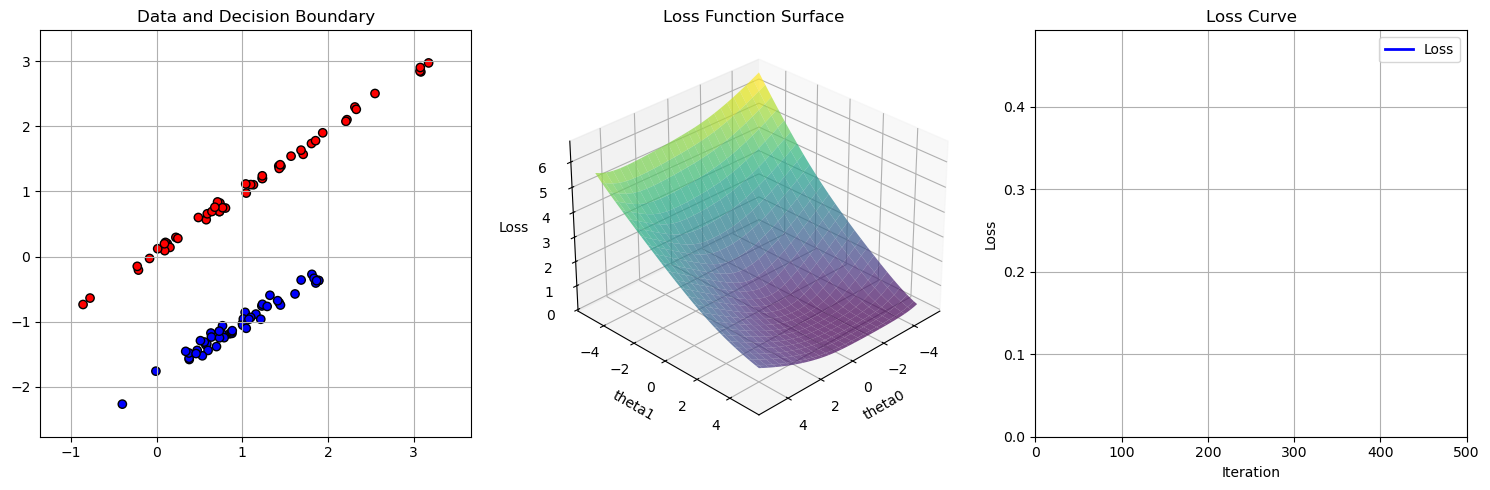

In [ ]:
"""
Author: Yanzeng Li
Date: 2025-10-13
Description: 使用梯度下降解决二分类问题（逻辑回归）
"""
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.datasets import make_classification

np.random.seed(42)

# 生成二分类数据
n_samples = 100
X, y = make_classification(n_samples=n_samples, n_features=2, n_redundant=0, 
                          n_clusters_per_class=1, random_state=42)
y = y.reshape(-1, 1)

# 添加偏置项
X = np.hstack([X, np.ones((n_samples, 1))])

# 梯度下降参数
learning_rate = 0.2
n_iterations = 500

# 初始化参数
theta = np.random.rand(3, 1)
theta_history = []
loss_history = []

# 定义sigmoid函数
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 计算损失函数
def compute_loss(theta):
    z = X @ theta
    h = sigmoid(z)
    loss = -np.mean(y * np.log(h) + (1-y) * np.log(1-h))
    return loss

# 运行梯度下降
for i in range(n_iterations):
    # 计算预测值和误差
    z = X @ theta
    h = sigmoid(z)
    error = h - y
    
    # 计算梯度
    grad = X.T @ error / n_samples
    
    # 更新参数
    theta -= learning_rate * grad
    
    # 记录历史
    theta_history.append(theta.copy())
    loss_history.append(compute_loss(theta))

print(f"优化结果：theta = {theta.flatten()}")

"""
后面全部都是绘图和动画了
"""
# 创建网格用于绘制决策边界
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50),
                     np.linspace(y_min, y_max, 50))

fig = plt.figure(figsize=(15, 5))

# 图1: 数据点和决策边界
ax1 = fig.add_subplot(1, 3, 1)
scatter = ax1.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='bwr', edgecolors='k', label='Data points')
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)
ax1.set_title('Data and Decision Boundary')
ax1.grid(True)

# 图2: 损失函数曲面
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
theta0 = np.linspace(-5, 5, 50)
theta1 = np.linspace(-5, 5, 50)
T0, T1 = np.meshgrid(theta0, theta1)
loss = np.zeros_like(T0)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        loss[i,j] = compute_loss(np.array([T0[i,j], T1[i,j], theta_history[0][2][0]]).reshape(3,1))
ax2.plot_surface(T0, T1, loss, cmap='viridis', alpha=0.7, rstride=2, cstride=2)
path = ax2.plot([], [], [], 'r-', linewidth=2)[0]
point = ax2.plot([], [], [], 'ro')[0]
ax2.set_xlabel('theta0')
ax2.set_ylabel('theta1')
ax2.set_zlabel('Loss')
ax2.set_title('Loss Function Surface')
ax2.view_init(elev=30, azim=45)

# 图3: 损失函数变化曲线
ax3 = fig.add_subplot(1, 3, 3)
loss_line, = ax3.plot([], [], 'b-', linewidth=2, label='Loss')
current_point = ax3.plot([], [], 'ro')[0]
ax3.set_xlim(0, n_iterations)
ax3.set_ylim(0, max(loss_history)*1.1)
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Loss')
ax3.set_title('Loss Curve')
ax3.grid(True)
ax3.legend()

plt.tight_layout()

# 准备路径数据
theta0_history = [t[0][0] for t in theta_history]
theta1_history = [t[1][0] for t in theta_history]
path_loss_history = [compute_loss(np.array([t0, t1, theta_history[0][2][0]]).reshape(3,1)) 
                    for t0, t1 in zip(theta0_history, theta1_history)]

def update(frame):
    current_theta = theta_history[frame]
    
    # 计算当前决策边界
    Z = sigmoid(current_theta[0]*xx + current_theta[1]*yy + current_theta[2])
    
    # 更新第一个子图
    ax1.clear()
    ax1.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='bwr', edgecolors='k', label='Data points')
    ax1.contour(xx, yy, Z, levels=[0.5], colors='red', linewidths=2)
    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(y_min, y_max)
    ax1.set_title(f'Iteration {frame}: θ0={current_theta[0][0]:.2f}, θ1={current_theta[1][0]:.2f}')
    ax1.grid(True)
    
    # 更新3D路径
    path.set_data(theta0_history[:frame+1], theta1_history[:frame+1])
    path.set_3d_properties(path_loss_history[:frame+1])
    point.set_data([theta0_history[frame]], [theta1_history[frame]])
    point.set_3d_properties([path_loss_history[frame]])
    
    # 更新损失曲线
    loss_line.set_data(range(frame+1), loss_history[:frame+1])
    current_point.set_data([frame], [loss_history[frame]])
    
    return scatter, path, point, loss_line, current_point

ani = FuncAnimation(
    fig, 
    update, 
    frames=range(n_iterations),
    interval=20,
    blit=False,
    cache_frame_data=False,
    repeat=False
)

plt.ion()
plt.show(block=True)

while True:
    plt.pause(0.1)